# Task 3 - Valutazione su campioni misti QCD + EJ

Questo notebook **non allena** nuovi modelli: prende gli anomaly-score gia' prodotti
dai 6 modelli unsupervised (Task 2) e li **confronta** in modo sistematico, aggiungendo
due classificatori **supervisionati** come tetto di riferimento.

**Cosa consegna la Task 3:**
1. distribuzioni dell'anomaly-score QCD vs EJ;
2. curve ROC + AUC consolidate;
3. curve *efficiency vs mistag rate*;
4. **sensibilita' in funzione del decay length** dell'LLP (e, come studio supplementare, della massa ricostruita del jet);
5. **confronto con un approccio supervisionato** (MLP + boosted decision trees);
6. interpretabilita' (permutation importance + visualizzazione dello spazio latente).

**Da dove vengono gli score unsupervised?** Ogni notebook `02..07` salva i propri score in
`task3_scores/<modello>.npz` (cella "Export per la Task 3"). Qui li ricarichiamo. I `.npz`
ancora mancanti vengono semplicemente saltati: i supervisionati, invece, vengono allenati
qui e leggono i dati direttamente, quindi il notebook gira anche senza alcun `.npz`.

## 1. Setup e caricamento dati

Importiamo le utility del progetto e ricostruiamo l'embedding **aggregate 43-dim** (lo stesso
input "onesto" usato dai modelli tabellari): per ogni jet `[media, max, std]` delle 14 feature
di traccia + `log(n_tracce)`. Le feature "magiche" del tagger (Tau\*, ECF\*, isTagged, ...) sono
**escluse** da tutti i modelli, supervisionati compresi: userebbero "la risposta travestita da feature".

In [78]:
import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = r"C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\ej_anomaly"
sys.path.insert(0, PROJECT_DIR)
from Utils_NEW import (load_tracks, load_jets, clean_tracks, zscore_normalise,
                       make_aggregate_embeddings, compute_roc, TRACK_FEATURES)

BKG_FILE  = r"C:\Users\dfraj\Downloads\pp_output_test_background.h5"
SIG_FILE  = r"C:\Users\dfraj\Downloads\pp_output_test_signal.h5"
TASK3_DIR = os.path.join(PROJECT_DIR, "notebooks_locali", "task3_scores")
PLOTS_DIR = os.path.join(PROJECT_DIR, "plots"); os.makedirs(PLOTS_DIR, exist_ok=True)

N_BKG = 50_000          # jet QCD usati (coerente con i notebook dei modelli)
SEED  = 42
rng   = np.random.default_rng(SEED)

# nomi delle 43 feature aggregate: [mean, max, std] x 14 + log_n
AGG_NAMES = ([f"{f}_mean" for f in TRACK_FEATURES] +
             [f"{f}_max"  for f in TRACK_FEATURES] +
             [f"{f}_std"  for f in TRACK_FEATURES] + ["log_n_tracks"])
print("Feature aggregate:", len(AGG_NAMES))

Feature aggregate: 43


In [79]:
def build_aggregate(path, n_max=None):
    """H5 -> embedding aggregate (N, 43). Libera gli array intermedi per la RAM."""
    tr   = load_tracks(path, n_max=n_max)
    mask = tr["valid"].astype(bool)
    Xc, mask = clean_tracks(tr, mask)
    Xn = zscore_normalise(Xc, mask)
    emb = make_aggregate_embeddings(Xn, mask)
    del tr, Xc, Xn, mask
    return emb.astype(np.float32)

print("Carico QCD (background)...")
X_bkg = build_aggregate(BKG_FILE, n_max=N_BKG)
print("Carico EJ (signal)...")
X_sig = build_aggregate(SIG_FILE, n_max=None)
N_b, N_s = len(X_bkg), len(X_sig)
print(f"X_bkg: {X_bkg.shape} | X_sig: {X_sig.shape}")

Carico QCD (background)...
Carico EJ (signal)...
X_bkg: (50000, 43) | X_sig: (61966, 43)


## 2. Caricamento degli anomaly-score unsupervised

Convenzione comune a tutti i modelli: **score piu' alto = jet piu' anomalo**. Ogni `.npz` contiene
`scores_bkg` (QCD di test), `scores_sig` (segnale), e gli indici `idx_sig`/`idx_bkg` che permettono
di riagganciare ogni jet alla sua verita' di simulazione (decay length, massa).

In [80]:
# MODELS: dizionario nome -> dict con gli array di score e gli indici originali
MODELS = {}

def register(name, scores_bkg, scores_sig, idx_sig, idx_bkg=None, kind="unsup"):
    MODELS[name] = dict(scores_bkg=np.asarray(scores_bkg, np.float64),
                        scores_sig=np.asarray(scores_sig, np.float64),
                        idx_sig=np.asarray(idx_sig, np.int64),
                        idx_bkg=(np.asarray(idx_bkg, np.int64) if idx_bkg is not None else None),
                        kind=kind)

for fn in sorted(glob.glob(os.path.join(TASK3_DIR, "*.npz"))):
    d = np.load(fn, allow_pickle=True)
    name = str(d["model_name"]) if "model_name" in d else os.path.basename(fn)[:-4]
    register(name, d["scores_bkg"], d["scores_sig"], d["idx_sig"],
             d["idx_bkg"] if "idx_bkg" in d else None, kind="unsup")
    print(f"  caricato: {name:28s} | bkg {len(d['scores_bkg']):>6,} | sig {len(d['scores_sig']):>6,}")

if not MODELS:
    print("Nessun .npz trovato in", TASK3_DIR)
    print("-> Rigira i notebook 02..07 (o solo la loro cella di export se il kernel e' vivo).")
    print("   Il notebook funziona comunque: qui sotto alleniamo i supervisionati.")

  caricato: AE                           | bkg  7,500 | sig 61,966
  caricato: Diffusion                    | bkg  7,500 | sig 61,966
  caricato: GNN EdgeConv                 | bkg  7,500 | sig 50,000
  caricato: GNN attenzione (Transformer) | bkg  7,500 | sig 50,000
  caricato: NF RealNVP                   | bkg  7,500 | sig 61,966
  caricato: VAE                          | bkg  7,500 | sig 61,966


## 3. Tetto di riferimento: due classificatori supervisionati

I modelli unsupervised non vedono mai il segnale: imparano solo "com'e' fatto il QCD" e segnalano
cio' che e' diverso. Un **supervisionato** invece usa le etichette (QCD=0, EJ=1) in training: e' il
**limite superiore** di quanto si puo' separare con questo input. Gli unsupervised stanno (giustamente) sotto.

Ne alleniamo **due, separati** (non in ensemble), perche' il "tetto" deve essere una proprieta'
**dei dati**, non dell'architettura:

* **MLP (rete neurale, loss BCE)** - *apprende una rappresentazione*: combina in modo non lineare e
  liscio le 43 feature. E' la controparte supervisionata dei nostri autoencoder.
* **Boosted Decision Trees** (XGBoost se installato, altrimenti `HistGradientBoosting` di sklearn -
  stessa famiglia) - *non* apprende una rappresentazione: costruisce tanti alberi che mettono **soglie**
  sulle feature e ne catturano interazioni. E' lo standard sui dati **tabellari**.

Se i due danno AUC simili, il tetto e' robusto e il confronto con gli unsupervised e' solido.

**Importante:** split con **entrambe le classi**; valutiamo sul *test* mai visto. Teniamo traccia
degli indici originali dei jet di test, cosi' anche i supervisionati entrano negli studi di sensibilita'.

In [81]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def split_idx(n, f_tr=0.7, f_va=0.15, seed=SEED):
    p = np.random.default_rng(seed).permutation(n)
    a, b = int(f_tr*n), int((f_tr+f_va)*n)
    return p[:a], p[a:b], p[b:]

# split per-classe (cosi' gli indici originali restano semplici da tracciare)
b_tr, b_va, b_te = split_idx(N_b, seed=SEED)
s_tr, s_va, s_te = split_idx(N_s, seed=SEED+1)

Xtr = np.vstack([X_bkg[b_tr], X_sig[s_tr]]); ytr = np.r_[np.zeros(len(b_tr)), np.ones(len(s_tr))]
Xva = np.vstack([X_bkg[b_va], X_sig[s_va]]); yva = np.r_[np.zeros(len(b_va)), np.ones(len(s_va))]
# test tenuti separati per classe: servono come scores_bkg / scores_sig
Xbte, Xste = X_bkg[b_te], X_sig[s_te]

scaler = StandardScaler().fit(Xtr)           # fit SOLO sul train
Xtr_s, Xva_s = scaler.transform(Xtr), scaler.transform(Xva)
Xbte_s, Xste_s = scaler.transform(Xbte), scaler.transform(Xste)
print(f"train {len(Xtr):,} | val {len(Xva):,} | test QCD {len(Xbte):,} + EJ {len(Xste):,}")

train 78,376 | val 16,795 | test QCD 7,500 + EJ 9,295


In [82]:
# ---- Supervised #1: MLP in PyTorch ----
import torch, torch.nn as nn
torch.manual_seed(SEED)
dev = "cuda" if torch.cuda.is_available() else "cpu"

class MLP(nn.Module):
    def __init__(self, d_in, h=(64, 32)):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, h[0]), nn.ReLU(),
                                 nn.Linear(h[0], h[1]), nn.ReLU(),
                                 nn.Linear(h[1], 1))
    def forward(self, x): return self.net(x).squeeze(-1)

mlp = MLP(Xtr_s.shape[1]).to(dev)
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-5)
lossf = nn.BCEWithLogitsLoss()

Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32, device=dev)
ytr_t = torch.tensor(ytr,  dtype=torch.float32, device=dev)
Xva_t = torch.tensor(Xva_s, dtype=torch.float32, device=dev)

best_auc, best_state = 0.0, None
bs = 512
for epoch in range(40):
    mlp.train()
    perm = torch.randperm(len(Xtr_t), device=dev)
    for i in range(0, len(perm), bs):
        j = perm[i:i+bs]
        opt.zero_grad()
        loss = lossf(mlp(Xtr_t[j]), ytr_t[j]); loss.backward(); opt.step()
    mlp.eval()
    with torch.no_grad():
        va_prob = torch.sigmoid(mlp(Xva_t)).cpu().numpy()
    a = roc_auc_score(yva, va_prob)
    if a > best_auc:
        best_auc, best_state = a, {k: v.clone() for k, v in mlp.state_dict().items()}
mlp.load_state_dict(best_state)
print(f"MLP - miglior AUC di validazione: {best_auc:.4f}")

mlp.eval()
with torch.no_grad():
    sc_b_mlp = torch.sigmoid(mlp(torch.tensor(Xbte_s, dtype=torch.float32, device=dev))).cpu().numpy()
    sc_s_mlp = torch.sigmoid(mlp(torch.tensor(Xste_s, dtype=torch.float32, device=dev))).cpu().numpy()
register("Supervised MLP", sc_b_mlp, sc_s_mlp, idx_sig=s_te, idx_bkg=b_te, kind="sup")
print(f"MLP - AUC di test: {roc_auc_score(np.r_[np.zeros(len(sc_b_mlp)), np.ones(len(sc_s_mlp))], np.r_[sc_b_mlp, sc_s_mlp]):.4f}")

MLP - miglior AUC di validazione: 0.9840
MLP - AUC di test: 0.9840


In [83]:
# ---- Supervised #2: Boosted Decision Trees ----
try:
    from xgboost import XGBClassifier
    bdt = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                        subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
                        n_jobs=-1, random_state=SEED)
    bdt_name = "Supervised XGBoost"
except Exception as e:
    from sklearn.ensemble import HistGradientBoostingClassifier
    bdt = HistGradientBoostingClassifier(max_iter=300, max_depth=4,
                                          learning_rate=0.1, random_state=SEED)
    bdt_name = "Supervised BDT (HistGB)"
    print("xgboost non disponibile -> uso sklearn HistGradientBoosting.")

# gli alberi non hanno bisogno di standardizzazione: usiamo le feature grezze
bdt.fit(Xtr, ytr)
sc_b_bdt = bdt.predict_proba(Xbte)[:, 1]
sc_s_bdt = bdt.predict_proba(Xste)[:, 1]
register(bdt_name, sc_b_bdt, sc_s_bdt, idx_sig=s_te, idx_bkg=b_te, kind="sup")
print(f"{bdt_name} - AUC di test: {roc_auc_score(np.r_[np.zeros(len(sc_b_bdt)), np.ones(len(sc_s_bdt))], np.r_[sc_b_bdt, sc_s_bdt]):.4f}")

xgboost non disponibile -> uso sklearn HistGradientBoosting.
Supervised BDT (HistGB) - AUC di test: 0.9833


## 4. Distribuzioni dello score: QCD vs EJ

Per ogni modello, l'istogramma (normalizzato) dell'anomaly-score di QCD e di EJ. Piu' le due
distribuzioni sono **separate**, meglio il modello distingue i jet anomali. Tagliamo la coda al 99-esimo
percentile solo per la leggibilita' del grafico.

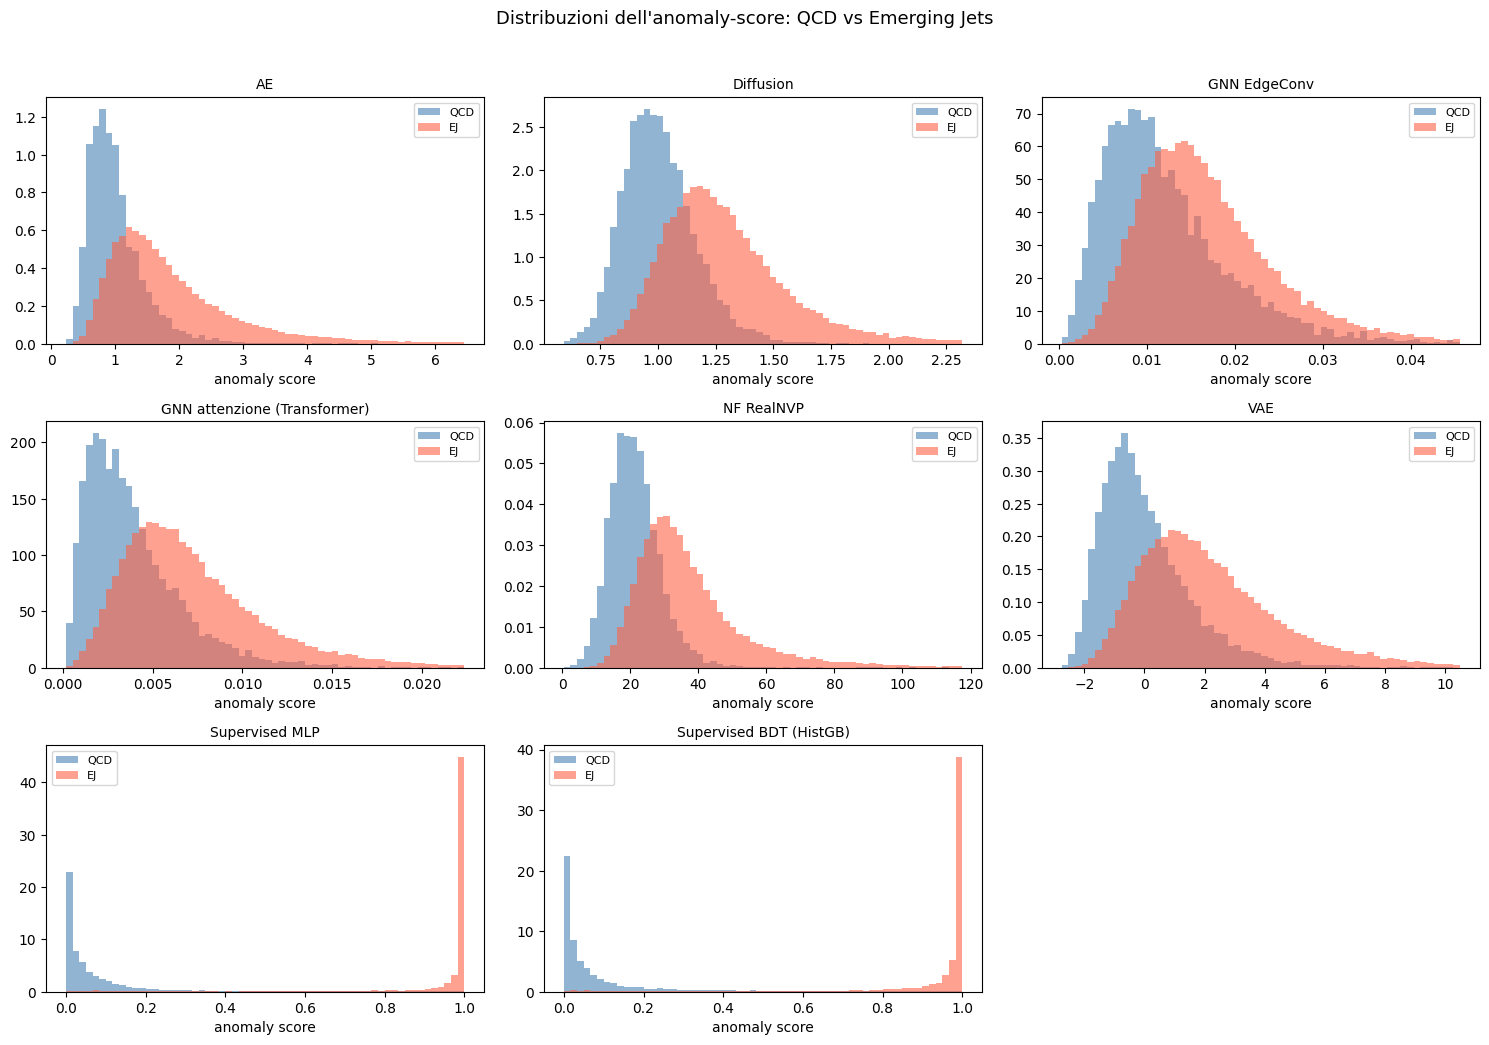

In [84]:
names = list(MODELS.keys())
ncol = 3; nrow = int(np.ceil(len(names)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 3.4*nrow))
axes = np.atleast_1d(axes).ravel()
for ax, name in zip(axes, names):
    sb, ss = MODELS[name]["scores_bkg"], MODELS[name]["scores_sig"]
    hi = np.percentile(np.r_[sb, ss], 99)
    rng_ = (min(sb.min(), ss.min()), hi)
    ax.hist(sb, bins=60, range=rng_, density=True, alpha=0.6, label="QCD", color="steelblue")
    ax.hist(ss, bins=60, range=rng_, density=True, alpha=0.6, label="EJ", color="tomato")
    ax.set_title(name, fontsize=10); ax.set_xlabel("anomaly score"); ax.legend(fontsize=8)
for ax in axes[len(names):]: ax.axis("off")
fig.suptitle("Distribuzioni dell'anomaly-score: QCD vs Emerging Jets", y=1.02, fontsize=13)
fig.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "task3_score_distributions.png"), dpi=130, bbox_inches="tight"); plt.show()

## 5. Curve ROC e AUC

La **ROC** riassume la separazione a tutte le soglie: sull'asse x il *false positive rate* (QCD scambiato
per EJ), sull'asse y il *true positive rate* (EJ correttamente identificati). L'**AUC** e' l'area sotto la
curva: 0.5 = caso, 1.0 = separazione perfetta. Sovrapponiamo tutti i modelli; i supervisionati (tratteggiati)
sono il tetto di riferimento.

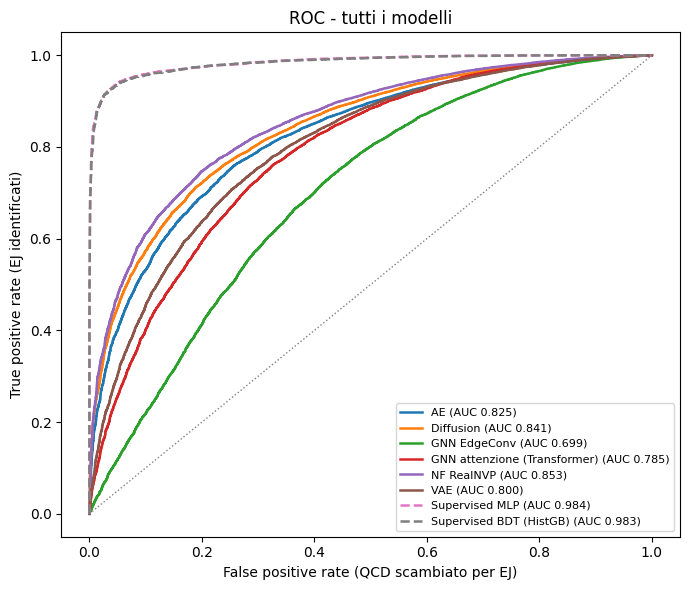

,modello,AUC,tipo
0,Supervised MLP,0.984044,sup
1,Supervised BDT (HistGB),0.983335,sup
2,NF RealNVP,0.852659,unsup
3,Diffusion,0.840812,unsup
4,AE,0.825403,unsup
5,VAE,0.800404,unsup
6,GNN attenzione (Transformer),0.784965,unsup
7,GNN EdgeConv,0.698985,unsup


In [85]:
import pandas as pd
fig, ax = plt.subplots(figsize=(7, 6))
rows = []
for name in names:
    sb, ss = MODELS[name]["scores_bkg"], MODELS[name]["scores_sig"]
    fpr, tpr, a = compute_roc(sb, ss)
    MODELS[name]["roc"] = (fpr, tpr, a)
    style = "--" if MODELS[name]["kind"] == "sup" else "-"
    ax.plot(fpr, tpr, style, lw=1.8, label=f"{name} (AUC {a:.3f})")
    rows.append((name, a, MODELS[name]["kind"]))
ax.plot([0, 1], [0, 1], ":", color="gray", lw=1)
ax.set_xlabel("False positive rate (QCD scambiato per EJ)")
ax.set_ylabel("True positive rate (EJ identificati)")
ax.set_title("ROC - tutti i modelli"); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "task3_roc_overlay.png"), dpi=130, bbox_inches="tight"); plt.show()

auc_table = (pd.DataFrame(rows, columns=["modello", "AUC", "tipo"])
             .sort_values("AUC", ascending=False).reset_index(drop=True))
display(auc_table)

## 6. SIC - Significance Improvement Characteristic

La **SIC** e' la metrica standard nei paper di anomaly detection al LHC (ATLAS, CMS). Risponde a:
*applicando un taglio sull'anomaly-score, di quanto migliora la significativita' statistica del segnale?*
E' definita come $\mathrm{SIC}(\varepsilon_S) = \varepsilon_S / \sqrt{\varepsilon_B}$ - signal efficiency
diviso radice del mistag rate - cioe' il guadagno in $S/\sqrt{B}$ rispetto a non tagliare. SIC > 1 indica
miglioramento; il **picco** (`SIC_max`) e' il taglio ottimale e dice **di quanto** si guadagna.

E' una rilettura della ROC ($\mathrm{SIC} = \mathrm{tpr}/\sqrt{\mathrm{fpr}}$), quindi la calcoliamo in modo
**uniforme per tutti i modelli** - inclusi NF e diffusion, dove nei notebook originali stampavamo solo il
numero `SIC_max` senza disegnare la curva.

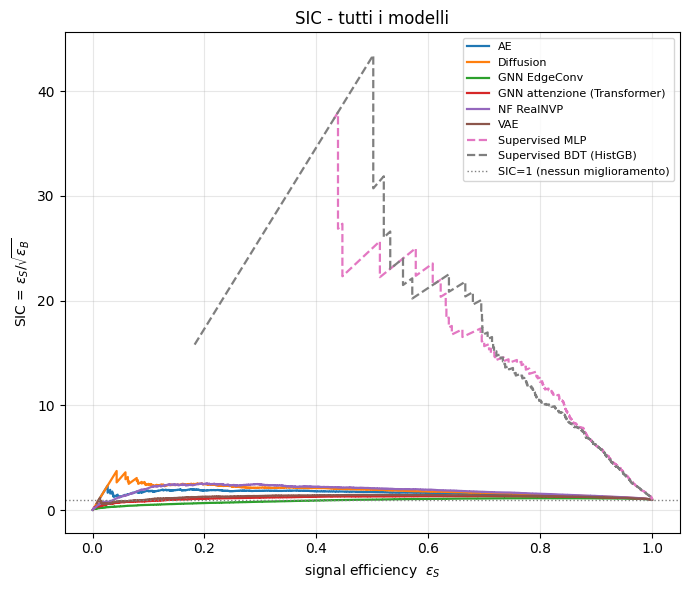

,modello,SIC_max,eps_S@max,mistag@max
0,Supervised BDT (HistGB),43.455003,0.501775,0.000133
1,Supervised MLP,37.995176,0.438731,0.000133
2,Diffusion,3.734338,0.043120,0.000133
3,NF RealNVP,2.550996,0.204080,0.006400
4,AE,2.342347,0.027047,0.000133
5,VAE,1.449653,0.483701,0.111333
6,GNN attenzione (Transformer),1.339110,0.712460,0.283067
7,GNN EdgeConv,1.134541,0.807360,0.506400


In [86]:
fig, ax = plt.subplots(figsize=(7, 6))
rows = []
for name in names:
    fpr, tpr, _ = MODELS[name]["roc"]
    m = fpr > 0
    sic = tpr[m] / np.sqrt(fpr[m]); eps = tpr[m]
    style = "--" if MODELS[name]["kind"] == "sup" else "-"
    ax.plot(eps, sic, style, lw=1.6, label=name)
    imax = int(sic.argmax())
    rows.append((name, sic[imax], eps[imax], fpr[m][imax]))
ax.axhline(1.0, color="gray", ls=":", lw=1, label="SIC=1 (nessun miglioramento)")
ax.set_xlabel(r"signal efficiency  $\varepsilon_S$")
ax.set_ylabel(r"SIC = $\varepsilon_S/\sqrt{\varepsilon_B}$")
ax.set_title("SIC - tutti i modelli"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "task3_sic.png"), dpi=130, bbox_inches="tight"); plt.show()

sic_table = (pd.DataFrame(rows, columns=["modello", "SIC_max", "eps_S@max", "mistag@max"])
             .sort_values("SIC_max", ascending=False).reset_index(drop=True))
display(sic_table)

## 7. Efficiency vs mistag rate

E' la stessa informazione della ROC, ma letta nel **linguaggio dell'analisi fisica**:

* **signal efficiency** ($\varepsilon_S$) = frazione di Emerging Jets che il modello **tiene** a una data soglia
  (= il *true positive rate*): "quanto segnale catturo".
* **mistag rate** ($\varepsilon_B$) = frazione di jet QCD che vengono **scambiati** per EJ (= il *false positive
  rate*): "quanto fondo mi entra per sbaglio".

Facciamo **scorrere la soglia** sull'anomaly-score: alzandola si tiene meno fondo (mistag piccolo) ma si perde
anche segnale. La curva mostra il compromesso. **Dati usati:** gli stessi `scores_bkg`/`scores_sig` di prima.
**A cosa serve:** in una ricerca reale ci si fissa un budget di fondo tollerabile (es. mistag = 1% o 0.1%) e si
legge **quanto segnale si tiene** li'. Mettiamo l'asse x (mistag) in **scala logaritmica** perche' la regione
interessante e' quella a basso fondo. La tabella riporta $\varepsilon_S$ a mistag fisso = 10% / 1% / 0.1%.

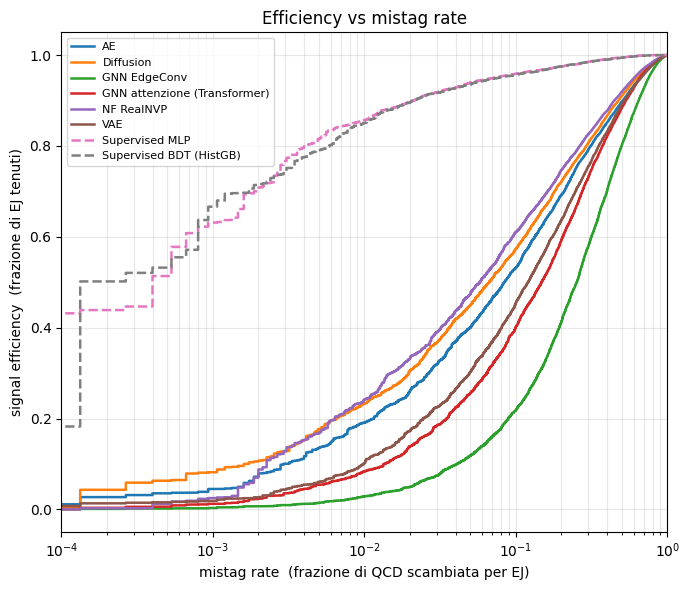

,modello,eff@mistag=10%,eff@mistag=1%,eff@mistag=0.1%
0,Supervised MLP,0.958687,0.857235,0.631307
1,Supervised BDT (HistGB),0.956751,0.850457,0.666272
2,NF RealNVP,0.609996,0.242165,0.024901
3,Diffusion,0.573234,0.233079,0.081738
4,AE,0.531824,0.191185,0.044928
5,VAE,0.454991,0.102314,0.018704
6,GNN attenzione (Transformer),0.401720,0.083680,0.012300
7,GNN EdgeConv,0.218360,0.028920,0.003140


In [87]:
fig, ax = plt.subplots(figsize=(7, 6))
targets = [1e-1, 1e-2, 1e-3]
rows = []
for name in names:
    fpr, tpr, a = MODELS[name]["roc"]
    style = "--" if MODELS[name]["kind"] == "sup" else "-"
    ax.plot(fpr, tpr, style, lw=1.8, label=name)
    effs = [np.interp(t, fpr, tpr) for t in targets]   # eff_S al mistag richiesto
    rows.append((name, *effs))
ax.set_xscale("log"); ax.set_xlim(1e-4, 1)
ax.set_xlabel("mistag rate  (frazione di QCD scambiata per EJ)")
ax.set_ylabel("signal efficiency  (frazione di EJ tenuti)")
ax.set_title("Efficiency vs mistag rate"); ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "task3_eff_vs_mistag.png"), dpi=130, bbox_inches="tight"); plt.show()

eff_table = (pd.DataFrame(rows, columns=["modello", "eff@mistag=10%", "eff@mistag=1%", "eff@mistag=0.1%"])
             .sort_values("eff@mistag=1%", ascending=False).reset_index(drop=True))
display(eff_table)

## 8. Sensibilita' vs decay length dell'LLP

E' il risultato fisico centrale del progetto. Gli Emerging Jets nascono dal decadimento **spostato** di
particelle a vita lunga (LLP, qui i *dark pions*): piu' il decadimento e' lontano dal punto di collisione,
piu' le tracce sono displaced -> piu' il jet "appare anomalo". Ci aspettiamo quindi che la sensibilita'
**cresca con il decay length**.

**Come lo misuriamo.** Dalla verita' di simulazione `truth_dark_pions` leggiamo $L_{xy}$ = raggio di
decadimento trasverso (distanza dal punto di collisione nel piano perpendicolare al fascio) del dark pion
**leading in $p_T$** di ogni jet di segnale.

**Cos'e' un "bin", e come lo scegliamo.** Un bin e' un **intervallo** di decay length: in ciascuno calcoliamo
l'AUC usando solo i jet di segnale con quel $L_{xy}$, contro **tutto** il QCD. I bordi li scegliamo **noi**
(non sono assegnati): qui **fisici** - fitti a piccolo $L_{xy}$ (dove la sensibilita' cambia in fretta) e piu'
larghi a grande $L_{xy}$. (In alternativa si potrebbero usare i quantili come nella sezione massa.) Piu' bin
= curva piu' dettagliata ma piu' rumorosa (meno jet per bin). Una AUC che sale con $L_{xy}$ conferma la fisica.

**Dove mettiamo il punto sull'asse x: la mediana del bin.** Un bin e' un intervallo, ma per disegnare un
punto serve **una** posizione x. Usiamo la **mediana** dei $L_{xy}$ dei jet del bin: il valore che lascia
meta' jet sotto e meta' sopra, cioe' **dove i jet stanno davvero**. E' piu' fedele del *centro geometrico*
(il punto medio dei bordi), che per un bin largo cadrebbe dove non c'e' quasi nessun jet, schiacciando la
curva. La tabella qui sotto riporta **sia centro sia mediana**, cosi' vedi la differenza nei numeri.

*Nota:* la massa dell'LLP in questo campione e' **fissa a 10 GeV**, quindi un analogo "scan in massa dell'LLP"
non e' possibile (un solo punto). Vedi la Sezione 9 per uno studio in funzione della massa **del jet ricostruito**.

In [88]:
# Lxy per ogni jet di segnale: dal dark pion leading in pT (e mediana come robustezza)
import h5py
with h5py.File(SIG_FILE, "r") as f:
    dp = f["truth_dark_pions"][:N_s]      # (N_s, 50) structured
vmask = dp["valid"].astype(bool)
pt_dp = np.where(vmask, dp["pt"], -1.0)
lead  = pt_dp.argmax(axis=1)
rows_ = np.arange(N_s)
Lxy_lead = dp["Lxy"][rows_, lead].astype(np.float64)
Lxy_med  = np.array([np.median(dp["Lxy"][i, vmask[i]]) if vmask[i].any() else np.nan for i in range(N_s)])
has_dp   = vmask.any(axis=1)
print(f"jet di segnale con >=1 dark pion valido: {has_dp.sum():,}/{N_s:,}")
print("Lxy leading [mm] percentili:", np.round(np.percentile(Lxy_lead[has_dp], [5,25,50,75,95]), 1))

jet di segnale con >=1 dark pion valido: 60,478/61,966
Lxy leading [mm] percentili: [ 11.   58.9 126.8 206.  279.9]


bin  da[mm]   a[mm]      EJ  centro  mediana
  1       0      15    4131     7.5      7.5
  2      15      40    6485    27.5     27.3
  3      40      80    9517    60.0     60.1
  4      80     140   12784   110.0    108.7
  5     140     220   14812   180.0    178.0
  6     220     300   12749   260.0    258.4


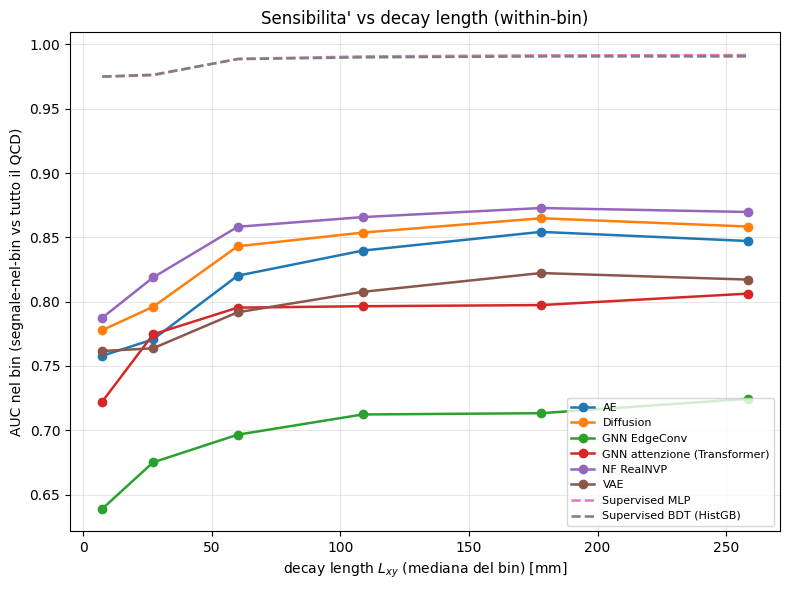

In [89]:
# 6 bin: bordi FISICI di decay length [mm], scelti da noi (fitti a piccolo Lxy, larghi a grande Lxy)
LXY_EDGES = np.array([0, 15, 40, 80, 140, 220, 300], dtype=float)
lxc = 0.5*(LXY_EDGES[:-1] + LXY_EDGES[1:])                       # centro dei bordi
_lx = Lxy_lead[has_dp]                                           # Lxy dei jet con dark pion
lxm = np.array([np.median(_lx[(_lx >= lo) & (_lx < hi)]) if ((_lx >= lo) & (_lx < hi)).sum() else np.nan
                for lo, hi in zip(LXY_EDGES[:-1], LXY_EDGES[1:])])   # Lxy tipico (mediana) nel bin

def auc_in_lxy_bins(model, lxy):
    sb = model["scores_bkg"]; ss = model["scores_sig"]; lx = lxy[model["idx_sig"]]
    out = []
    for lo, hi in zip(LXY_EDGES[:-1], LXY_EDGES[1:]):
        sel = (lx >= lo) & (lx < hi) & np.isfinite(lx)
        out.append(compute_roc(sb, ss[sel])[2] if sel.sum() >= 50 else np.nan)
    return out

# Tabella dei bin (li definiamo noi): bordi, n. jet di segnale, centro e mediana
print(f"{'bin':>3} {'da[mm]':>7} {'a[mm]':>7} {'EJ':>7} {'centro':>7} {'mediana':>8}")
for i, (lo, hi) in enumerate(zip(LXY_EDGES[:-1], LXY_EDGES[1:])):
    n = int(((_lx >= lo) & (_lx < hi)).sum())
    print(f"{i+1:>3} {lo:>7.0f} {hi:>7.0f} {n:>7} {lxc[i]:>7.1f} {lxm[i]:>8.1f}")

fig, ax = plt.subplots(figsize=(8, 6))
for name in names:
    style = "--" if MODELS[name]["kind"] == "sup" else "-o"
    ax.plot(lxm, auc_in_lxy_bins(MODELS[name], Lxy_lead), style, lw=1.8, label=name)   # x = mediana del bin
ax.set_xlabel("decay length $L_{xy}$ (mediana del bin) [mm]")
ax.set_ylabel("AUC nel bin (segnale-nel-bin vs tutto il QCD)")
ax.set_title("Sensibilita' vs decay length (within-bin)"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "task3_sensitivity_vs_lxy.png"), dpi=130, bbox_inches="tight"); plt.show()

## 9. Sensibilita' vs massa (del jet ricostruito) - studio supplementare

La massa dell'**LLP** e' fissa (10 GeV), quindi qui usiamo la massa **ricostruita del jet** (`jets['mass']`),
che varia jet per jet. **Attenzione - e' una grandezza diversa** dalla massa dell'LLP e va interpretata con
cautela: se segnale e fondo hanno spettri di massa diversi, un modello potrebbe "separare" sfruttando
banalmente quella differenza cinematica (*sculpting*), non una vera anomalia.

**Cos'e' un "bin".** Un bin e' un **intervallo** di massa. Spezziamo l'asse della massa in fette e, dentro
ciascuna, calcoliamo l'AUC usando **solo** i jet (segnale + QCD) la cui massa cade in quell'intervallo:
ogni punto della curva = "quanto separo *a quella massa*".

**Come scegliamo i bin (li definiamo noi, non sono assegnati).** Usiamo i **quantili** della massa combinata:
ogni bin contiene ~lo stesso numero di jet (*uguale occupazione*). Vantaggio: l'AUC per-bin e' stimata con
statistica comparabile ovunque, nessun bin quasi vuoto. Conseguenza: i bin a massa alta sono **larghi** (i
jet pesanti sono rari, quindi un solo bin copre un grande intervallo). L'alternativa - bin a **larghezza
fissa** - darebbe intervalli regolari ma con pochissimi jet (AUC rumorosa) alle masse alte. Il **numero di
bin** e' il parametro `N_MASS_BINS`: piu' bin = piu' dettaglio ma meno jet per bin (curva piu' rumorosa);
con ~7500 jet QCD di test, **7 bin** e' un buon compromesso (curva stabile e leggibile).

**Dove mettiamo il punto sull'asse x: la mediana del bin.** Disegniamo ogni punto alla **mediana** della
massa dei jet del bin (la massa che lascia meta' jet sotto e meta' sopra), cioe' **dove i jet stanno
davvero**. E' piu' rappresentativa del *centro geometrico* dell'intervallo: l'ultimo bin di massa e'
larghissimo (es. 240-1910 GeV) e il suo centro cadrebbe a ~1075 GeV, dove non c'e' quasi nessun jet,
schiacciando la curva; la mediana (~300 GeV) la rimette dove i jet sono davvero. La tabella riporta sia
centro sia mediana, cosi' vedi la differenza.

Per evitare lo *sculpting* binniamo **sia segnale sia fondo** nella stessa finestra di massa e calcoliamo
l'AUC **dentro ogni bin** (segnale-nel-bin vs QCD-nello-stesso-bin): cosi' misuriamo la separazione **a
parita' di massa**.

### I jet ad altissima massa sono rari --> quindi usiamo la **mediana = dove sta la maggioranza**.

 **Perché l'ultimo bin di massa è così largo (e centro ≠ mediana)?** Perché i jet ad
  altissima massa sono *rari*. Sui nostri dati (111.966 jet): la massa mediana è 138 GeV,
  il 99° percentile è 618 GeV, il massimo 1910 GeV. La frazione di jet **sopra** una soglia
  crolla in fretta:

  | massa | frazione di jet sopra |
  |------:|:----------------------|
  | > 250 GeV | 12.5% |
  | > 300 GeV | 7.1% |
  | > 500 GeV | 1.8% |
  | > 700 GeV | 0.7% |
  | > 1000 GeV | 0.2% |
  | > 1800 GeV | ~0% (2 jet) |

  Dato che i bin sono a **uguale occupazione** (ognuno ~lo stesso numero di jet), l'ultima
  fetta deve estendersi da ~250 fino a 1910 GeV per "riempirsi", ma quei jet sono quasi tutti
  addensati tra 250 e 400 GeV (10.591 jet), e si diradano subito (400–600 GeV: 2.240; 600–1000:
  960; 1000–2000: 251). Per questo la **mediana** del bin (~300 GeV) cade dove i jet stanno
  davvero, mentre il **centro geometrico** (~1075 GeV) cade in una zona quasi vuota: ecco perché
  sull'asse x usiamo la mediana.

bin  da[GeV]    a[GeV]    QCD      EJ   centro  mediana
  1      0.8      65.6  12873    3122     33.2     42.0
  2     65.6      97.3   8665    7330     81.4     82.7
  3     97.3     124.5   6077    9918    110.9    110.9
  4    124.5     152.6   4681   11314    138.6    138.1
  5    152.6     186.4   4144   11851    169.5    168.3
  6    186.4     240.0   4486   11509    213.2    208.8
  7    240.0    1910.5   9074    6922   1075.2    299.2


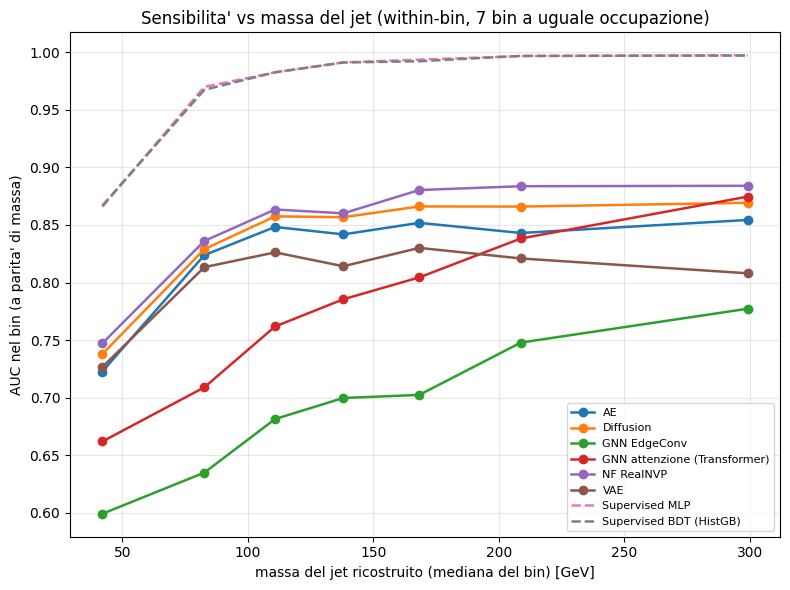

In [90]:
mass_sig = load_jets(SIG_FILE, features=["mass"], n_max=N_s)["mass"].astype(np.float64)
mass_bkg = load_jets(BKG_FILE, features=["mass"], n_max=N_b)["mass"].astype(np.float64)

N_MASS_BINS = 7                                          # manopola: piu' bin = piu' dettaglio, piu' rumore
allm = np.r_[mass_bkg, mass_sig]
M_EDGES = np.quantile(allm, np.linspace(0, 1, N_MASS_BINS + 1))   # bordi a UGUALE OCCUPAZIONE
M_EDGES[0] -= 1; M_EDGES[-1] += 1
mcenters = 0.5*(M_EDGES[:-1] + M_EDGES[1:])                                       # punto medio dei bordi
mmed = np.array([np.median(allm[(allm >= lo) & (allm < hi)])                      # massa tipica nel bin
                 for lo, hi in zip(M_EDGES[:-1], M_EDGES[1:])])

# Tabella dei bin: li abbiamo definiti NOI (quantili). Ecco bordi, conteggi, centro e mediana.
print(f"{'bin':>3} {'da[GeV]':>8} {'a[GeV]':>9} {'QCD':>6} {'EJ':>7} {'centro':>8} {'mediana':>8}")
for i, (lo, hi) in enumerate(zip(M_EDGES[:-1], M_EDGES[1:])):
    nbk = int(((mass_bkg >= lo) & (mass_bkg < hi)).sum()); nsg = int(((mass_sig >= lo) & (mass_sig < hi)).sum())
    print(f"{i+1:>3} {lo/1000:>8.1f} {hi/1000:>9.1f} {nbk:>6} {nsg:>7} {mcenters[i]/1000:>8.1f} {mmed[i]/1000:>8.1f}")

def auc_in_mass_bins(model):
    if model["idx_bkg"] is None: return None
    sb, ss = model["scores_bkg"], model["scores_sig"]
    mb, ms = mass_bkg[model["idx_bkg"]], mass_sig[model["idx_sig"]]
    out = []
    for lo, hi in zip(M_EDGES[:-1], M_EDGES[1:]):
        selb = (mb >= lo) & (mb < hi); sels = (ms >= lo) & (ms < hi)
        out.append(compute_roc(sb[selb], ss[sels])[2] if (selb.sum() >= 50 and sels.sum() >= 50) else np.nan)
    return out

fig, ax = plt.subplots(figsize=(8, 6))
for name in names:
    res = auc_in_mass_bins(MODELS[name])
    if res is None: continue
    style = "--" if MODELS[name]["kind"] == "sup" else "-o"
    ax.plot(mmed/1000, res, style, lw=1.8, label=name)   # x = mediana del bin (MeV -> GeV)
ax.set_xlabel("massa del jet ricostruito (mediana del bin) [GeV]")
ax.set_ylabel("AUC nel bin (a parita' di massa)")
ax.set_title(f"Sensibilita' vs massa del jet (within-bin, {N_MASS_BINS} bin a uguale occupazione)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "task3_sensitivity_vs_mass.png"), dpi=130, bbox_inches="tight"); plt.show()

## 10. Interpretabilita'

**(a) Permutation importance** sul supervisionato MLP. Idea: una volta allenato il modello, prendiamo il test
set e **mescoliamo a caso i valori di una sola feature** tra i jet, distruggendone l'informazione, poi
rimisuriamo l'AUC. Se l'AUC **crolla**, quella feature era importante; se non cambia, era irrilevante. Il calo
di AUC e' quindi una misura diretta di **quanto il modello si appoggia a ciascuna feature**. (E' agnostico al
modello e onesto: non guarda i pesi interni, guarda l'effetto sulle prestazioni.)

**(b) Spazio di input vs rappresentazione appresa.** Due proiezioni 2D (PCA), QCD vs EJ a colori:
- a **sinistra** lo **spazio di input** (le 43 feature aggregate) - cio' che i modelli "vedono" *prima* di
  imparare: QCD ed EJ **si sovrappongono molto** (separarli e' un problema difficile, ed e' la situazione in
  cui lavorano gli unsupervised);
- a **destra** la **rappresentazione interna del supervisionato** (ultimo strato nascosto dell'MLP): dopo aver
  imparato *con le etichette*, la rete **ridispone** i jet in modo che le due classi si separino.

Il contrasto rende visivo cosa "comprano" le etichette - e perche' un modello che vede solo lo spazio di
sinistra faccia piu' fatica.

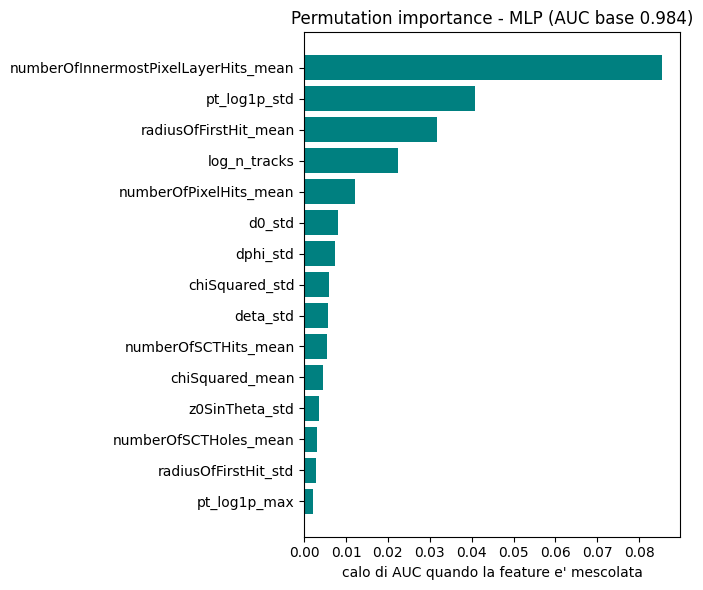

In [91]:
# (a) Permutation importance sul MLP (sul test set standardizzato)
Xte_s = np.vstack([Xbte_s, Xste_s]); yte = np.r_[np.zeros(len(Xbte_s)), np.ones(len(Xste_s))]
def mlp_prob(Xs):
    mlp.eval()
    with torch.no_grad():
        return torch.sigmoid(mlp(torch.tensor(Xs, dtype=torch.float32, device=dev))).cpu().numpy()
base_auc = roc_auc_score(yte, mlp_prob(Xte_s))
imp = np.zeros(Xte_s.shape[1])
rng_pi = np.random.default_rng(SEED)
for j in range(Xte_s.shape[1]):
    Xp = Xte_s.copy(); rng_pi.shuffle(Xp[:, j])
    imp[j] = base_auc - roc_auc_score(yte, mlp_prob(Xp))
order = np.argsort(imp)[::-1][:15]
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh([AGG_NAMES[j] for j in order][::-1], imp[order][::-1], color="teal")
ax.set_xlabel("calo di AUC quando la feature e' mescolata")
ax.set_title(f"Permutation importance - MLP (AUC base {base_auc:.3f})")
fig.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "task3_perm_importance.png"), dpi=130, bbox_inches="tight"); plt.show()

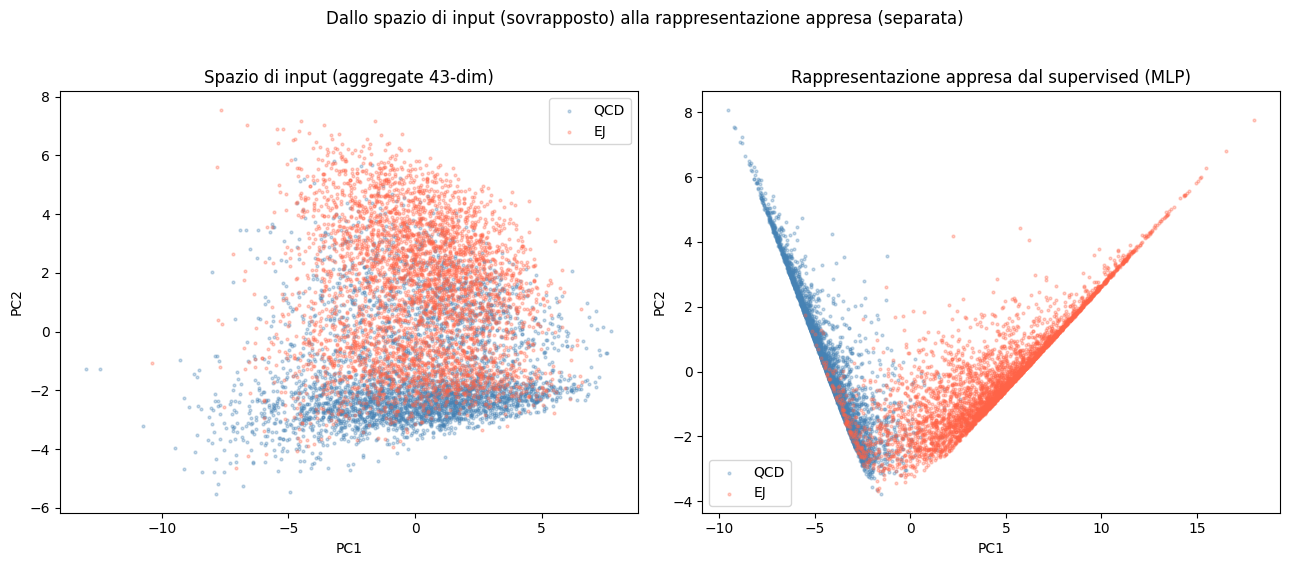

In [92]:
# (b) PCA: spazio di input (sovrapposto) vs rappresentazione appresa dal supervised (separata)
from sklearn.decomposition import PCA
nb_plot = min(4000, N_b); ns_plot = min(4000, N_s)
ib = rng.choice(N_b, nb_plot, replace=False); isg = rng.choice(N_s, ns_plot, replace=False)
Xin = scaler.transform(np.vstack([X_bkg[ib], X_sig[isg]])).astype(np.float32)
# rappresentazione appresa = attivazioni dell'ultimo strato nascosto dell'MLP (32-dim)
mlp.eval()
with torch.no_grad():
    hid = mlp.net[:4](torch.tensor(Xin, device=dev)).cpu().numpy()
P_in  = PCA(n_components=2).fit_transform(Xin)
P_hid = PCA(n_components=2).fit_transform(hid)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, P, title in [(axes[0], P_in,  "Spazio di input (aggregate 43-dim)"),
                     (axes[1], P_hid, "Rappresentazione appresa dal supervised (MLP)")]:
    ax.scatter(P[:nb_plot, 0], P[:nb_plot, 1], s=4, alpha=0.3, label="QCD", color="steelblue")
    ax.scatter(P[nb_plot:, 0], P[nb_plot:, 1], s=4, alpha=0.3, label="EJ", color="tomato")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title); ax.legend()
fig.suptitle("Dallo spazio di input (sovrapposto) alla rappresentazione appresa (separata)", y=1.02, fontsize=12)
fig.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "task3_latent_contrast.png"), dpi=130, bbox_inches="tight"); plt.show()

## 11. Sintesi

* **ROC/AUC ed efficiency-vs-mistag**: confronto consolidato dei 6 modelli unsupervised con il tetto
  supervisionato (MLP + BDT). Il gap unsupervised <-> supervised quantifica quanto si perde rinunciando alle
  etichette - il prezzo dell'essere model-independent.
* **Sensibilita' vs decay length**: il messaggio fisico - le informazioni a livello di traccia rendono i
  modelli piu' sensibili man mano che il decadimento e' piu' spostato.
* **Massa**: scan sulla massa dell'LLP non possibile (campione single-mass a 10 GeV); mostrato lo studio
  supplementare a parita' di massa del jet ricostruito.
* **Interpretabilita'**: le feature piu' usate dal supervisionato e una mappa 2D dello spazio.

> I numeri unsupervised si popolano man mano che si rigirano i notebook `02..07` (ognuno salva il proprio `.npz`).